In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


In [11]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


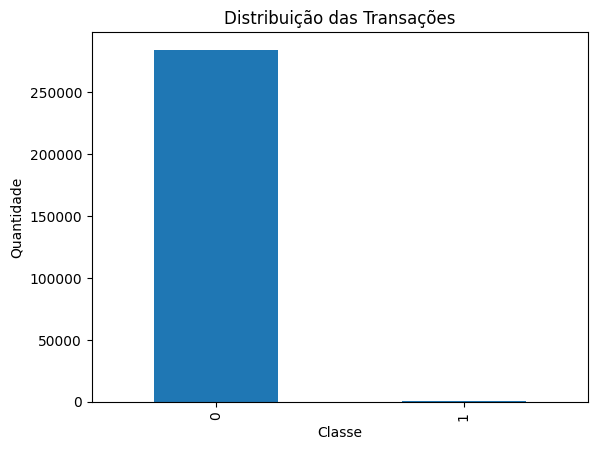

In [12]:
df["Class"].value_counts().plot(kind="bar")

plt.title("Distribuição das Transações")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

In [13]:
df["log_amount"] = np.log1p(df["Amount"])

In [14]:
df[["Amount", "log_amount"]].head()

,Amount,log_amount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [15]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [16]:
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (284807, 31)
Formato de y: (284807,)


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [24]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nFraudes no treino:")
print(y_train.value_counts())

print("\nFraudes no teste:")
print(y_test.value_counts())

Treino: (227845, 31)
Teste: (56962, 31)

Fraudes no treino:
Class
0    227451
1       394
Name: count, dtype: int64

Fraudes no teste:
Class
0    56864
1       98
Name: count, dtype: int64


In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
X_train_scaled = scaler.fit_transform(X_train)

In [28]:
X_test_scaled = scaler.transform(X_test)

In [29]:
print("Treino:", X_train_scaled.shape)
print("Teste:", X_test_scaled.shape)

Treino: (227845, 31)
Teste: (56962, 31)


Fase de Treinamento do primeiro Modelo

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
modelo_lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

In [32]:
modelo_lr.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [33]:
y_pred_lr = modelo_lr.predict(X_test_scaled)

In [34]:
from sklearn.metrics import classification_report

In [35]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [36]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

modelo_lr.fit(X_train_scaled, y_train) 

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [37]:
y_pred_lr = modelo_lr.predict(X_test_scaled)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [40]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[55483  1381]
 [    8    90]]


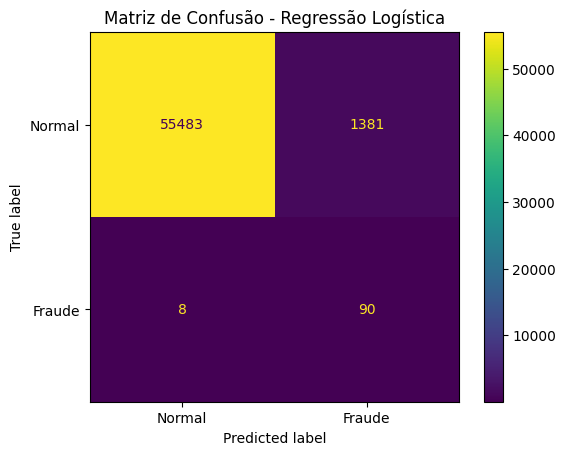

In [41]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraude"]
)

disp.plot()
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

In [42]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[55483  1381]
 [    8    90]]


In [43]:
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

y_prob_lr[:10]

array([5.98137979e-03, 6.49336666e-02, 1.38518057e-04, 1.38013260e-02,
       9.44196204e-01, 1.31316677e-02, 7.76570036e-04, 2.60728950e-02,
       6.51964159e-02, 4.63467441e-03])

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

auc_lr = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC:", auc_lr)

ROC-AUC: 0.9718520128225742


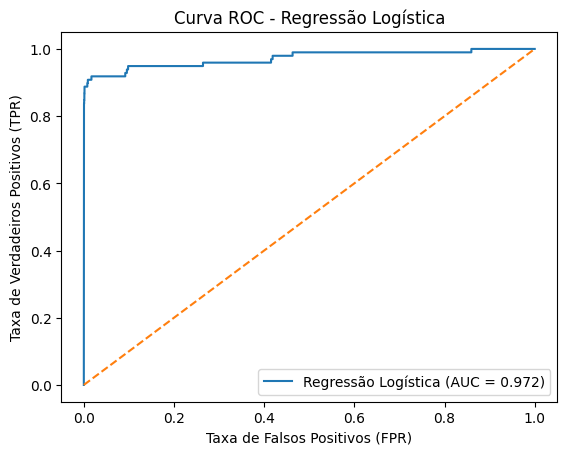

In [45]:
plt.plot(fpr, tpr, label=f"Regressão Logística (AUC = {auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC - Regressão Logística")
plt.legend()
plt.show()


In [46]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob_lr
)

ap_lr = average_precision_score(y_test, y_prob_lr)

print("Average Precision:", ap_lr)

Average Precision: 0.7194303169083883


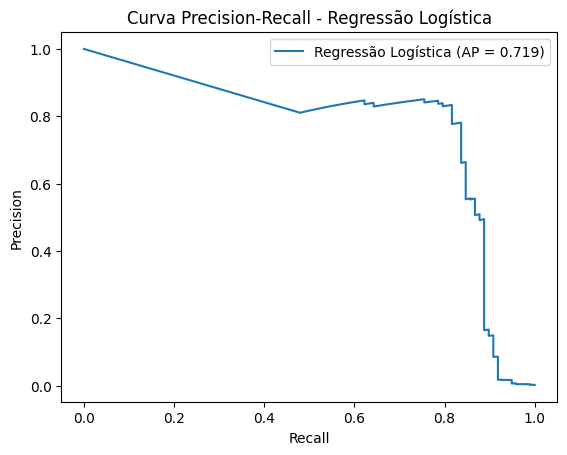

In [47]:
plt.plot(
    recall,
    precision,
    label=f"Regressão Logística (AP = {ap_lr:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Regressão Logística")
plt.legend()
plt.show()

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_testados = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds_testados:
    y_pred_threshold = (y_prob_lr >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.1 | Precision: 0.008 | Recall: 0.949 | F1: 0.016
Threshold: 0.2 | Precision: 0.016 | Recall: 0.949 | F1: 0.032
Threshold: 0.3 | Precision: 0.027 | Recall: 0.918 | F1: 0.053
Threshold: 0.4 | Precision: 0.042 | Recall: 0.918 | F1: 0.081
Threshold: 0.5 | Precision: 0.061 | Recall: 0.918 | F1: 0.115
Threshold: 0.6 | Precision: 0.087 | Recall: 0.908 | F1: 0.159
Threshold: 0.7 | Precision: 0.124 | Recall: 0.908 | F1: 0.218
Threshold: 0.8 | Precision: 0.162 | Recall: 0.898 | F1: 0.275
Threshold: 0.9 | Precision: 0.248 | Recall: 0.888 | F1: 0.388


In [49]:
from sklearn.model_selection import train_test_split

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Treinamento:", X_train_model.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treinamento: (182276, 31)
Validação: (45569, 31)
Teste: (56962, 31)


In [50]:
scaler_val = StandardScaler()

X_train_model_scaled = scaler_val.fit_transform(X_train_model)
X_val_scaled = scaler_val.transform(X_val)
X_test_scaled_final = scaler_val.transform(X_test)

In [51]:
print("Treinamento:", X_train_model_scaled.shape)
print("Validação:", X_val_scaled.shape)
print("Teste:", X_test_scaled_final.shape)

Treinamento: (182276, 31)
Validação: (45569, 31)
Teste: (56962, 31)


In [52]:
modelo_lr_val = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

modelo_lr_val.fit(X_train_model_scaled, y_train_model)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [53]:
y_prob_val = modelo_lr_val.predict_proba(X_val_scaled)[:, 1]

In [54]:
y_prob_val[:10]

array([0.04879433, 0.11944497, 0.00106782, 0.00250179, 0.00105375,
       0.01144035, 0.00635033, 0.04687511, 0.18349873, 0.00941509])

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_testados = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds_testados:
    y_pred_val = (y_prob_val >= threshold).astype(int)

    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.1 | Precision: 0.010 | Recall: 0.949 | F1: 0.019
Threshold: 0.2 | Precision: 0.018 | Recall: 0.911 | F1: 0.036
Threshold: 0.3 | Precision: 0.030 | Recall: 0.911 | F1: 0.058
Threshold: 0.4 | Precision: 0.042 | Recall: 0.886 | F1: 0.080
Threshold: 0.5 | Precision: 0.059 | Recall: 0.886 | F1: 0.111
Threshold: 0.6 | Precision: 0.082 | Recall: 0.861 | F1: 0.149
Threshold: 0.7 | Precision: 0.114 | Recall: 0.861 | F1: 0.202
Threshold: 0.8 | Precision: 0.150 | Recall: 0.848 | F1: 0.255
Threshold: 0.9 | Precision: 0.218 | Recall: 0.810 | F1: 0.343


In [56]:
thresholds = np.arange(0.01, 1.00, 0.01)

resultados_threshold = []

for threshold in thresholds:
    y_pred_val = (y_prob_val >= threshold).astype(int)

    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)

    resultados_threshold.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

resultados_threshold = pd.DataFrame(resultados_threshold)

resultados_threshold.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1
98,0.99,0.520661,0.797468,0.630000
97,0.98,0.444444,0.810127,0.573991
96,0.97,0.383234,0.810127,0.520325
95,0.96,0.333333,0.810127,0.472325
94,0.95,0.301887,0.810127,0.439863
93,0.94,0.278261,0.810127,0.414239
92,0.93,0.256000,0.810127,0.389058
91,0.92,0.236162,0.810127,0.365714
90,0.91,0.222997,0.810127,0.349727
89,0.90,0.217687,0.810127,0.343164


In [57]:
y_prob_test = modelo_lr_val.predict_proba(X_test_scaled_final)[:, 1]

In [58]:
threshold_final = 0.99

y_pred_test = (y_prob_test >= threshold_final).astype(int)

In [59]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.85      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.92      0.83     56962
weighted avg       1.00      1.00      1.00     56962



Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [62]:
modelo_rf.fit(X_train_model, y_train_model)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [63]:
y_prob_val_rf = modelo_rf.predict_proba(X_val)[:, 1]


In [64]:
y_prob_val_rf[:10]

array([0.  , 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

In [65]:
thresholds = np.arange(0.01, 1.00, 0.01)

resultados_threshold_rf = []

for threshold in thresholds:
    y_pred_val_rf = (y_prob_val_rf >= threshold).astype(int)

    precision = precision_score(y_val, y_pred_val_rf)
    recall = recall_score(y_val, y_pred_val_rf)
    f1 = f1_score(y_val, y_pred_val_rf)

    resultados_threshold_rf.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

resultados_threshold_rf = pd.DataFrame(resultados_threshold_rf)

resultados_threshold_rf.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1
44,0.45,0.911765,0.784810,0.843537
42,0.43,0.911765,0.784810,0.843537
41,0.42,0.911765,0.784810,0.843537
43,0.44,0.911765,0.784810,0.843537
40,0.41,0.898551,0.784810,0.837838
39,0.40,0.885714,0.784810,0.832215
37,0.38,0.885714,0.784810,0.832215
38,0.39,0.885714,0.784810,0.832215
45,0.46,0.909091,0.759494,0.827586
48,0.49,0.909091,0.759494,0.827586


In [66]:
y_prob_test_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [67]:
threshold_rf = 0.42

y_pred_test_rf = (y_prob_test_rf >= threshold_rf).astype(int)

In [68]:
print(classification_report(y_test, y_pred_test_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [69]:
cm_rf = confusion_matrix(y_test, y_pred_test_rf)

print(cm_rf)

[[56854    10]
 [   16    82]]


In [71]:
from xgboost import XGBClassifier

In [72]:
peso_classe = (
    y_train_model.value_counts()[0]
    / y_train_model.value_counts()[1]
)

print("Scale Pos Weight:", peso_classe)

Scale Pos Weight: 577.6539682539683


In [73]:
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=peso_classe,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)


In [74]:
modelo_xgb.fit(
    X_train_model,
    y_train_model
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [75]:
y_prob_val_xgb = modelo_xgb.predict_proba(X_val)[:, 1]

y_prob_val_xgb[:10]

array([0.00812627, 0.00975278, 0.00022604, 0.00022817, 0.00169293,
       0.00063615, 0.0007665 , 0.00762956, 0.00731432, 0.00700898],
      dtype=float32)

In [76]:
thresholds = np.arange(0.01, 1.00, 0.01)

resultados_threshold_xgb = []

for threshold in thresholds:
    y_pred_val_xgb = (y_prob_val_xgb >= threshold).astype(int)

    precision = precision_score(y_val, y_pred_val_xgb)
    recall = recall_score(y_val, y_pred_val_xgb)
    f1 = f1_score(y_val, y_pred_val_xgb)

    resultados_threshold_xgb.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

resultados_threshold_xgb = pd.DataFrame(resultados_threshold_xgb)

resultados_threshold_xgb.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
98,0.99,0.895522,0.759494,0.821918
94,0.95,0.871429,0.772152,0.818792
95,0.96,0.871429,0.772152,0.818792
96,0.97,0.871429,0.772152,0.818792
97,0.98,0.871429,0.772152,0.818792
91,0.92,0.837838,0.784810,0.810458
90,0.91,0.826667,0.784810,0.805195
89,0.90,0.826667,0.784810,0.805195
87,0.88,0.826667,0.784810,0.805195
88,0.89,0.826667,0.784810,0.805195


In [77]:
y_prob_test_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

threshold_xgb = 0.99

y_pred_test_xgb = (y_prob_test_xgb >= threshold_xgb).astype(int)

print(classification_report(y_test, y_pred_test_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.78      0.80        98

    accuracy                           1.00     56962
   macro avg       0.91      0.89      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [78]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(
    y_test,
    y_prob_test_xgb
)

auc_xgb = roc_auc_score(
    y_test,
    y_prob_test_xgb
)

print("ROC-AUC:", auc_xgb)

ROC-AUC: 0.9827375449335615


In [79]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_xgb, recall_xgb, thresholds_pr_xgb = precision_recall_curve(
    y_test,
    y_prob_test_xgb
)

ap_xgb = average_precision_score(
    y_test,
    y_prob_test_xgb
)

print("Average Precision:", ap_xgb)

Average Precision: 0.8112093102722555


In [81]:
from imblearn.under_sampling import RandomUnderSampler

In [82]:
undersampler = RandomUnderSampler(
    sampling_strategy=1.0,
    random_state=42
)

In [83]:
X_train_under, y_train_under = undersampler.fit_resample(
    X_train_model,
    y_train_model
)

In [84]:
print("Formato:", X_train_under.shape)
print("\nDistribuição das classes:")
print(y_train_under.value_counts())

Formato: (630, 31)

Distribuição das classes:
Class
0    315
1    315
Name: count, dtype: int64


In [85]:
modelo_rf_under = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo_rf_under.fit(
    X_train_under,
    y_train_under
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [86]:
y_prob_val_rf_under = modelo_rf_under.predict_proba(X_val)[:, 1]

y_prob_val_rf_under[:10]

array([0.02, 0.4 , 0.08, 0.03, 0.16, 0.  , 0.17, 0.13, 0.07, 0.02])

In [87]:
thresholds = np.arange(0.01, 1.00, 0.01)

resultados_threshold_rf_under = []

for threshold in thresholds:
    y_pred_val_rf_under = (
        y_prob_val_rf_under >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred_val_rf_under
    )

    recall = recall_score(
        y_val,
        y_pred_val_rf_under
    )

    f1 = f1_score(
        y_val,
        y_pred_val_rf_under
    )

    resultados_threshold_rf_under.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

resultados_threshold_rf_under = pd.DataFrame(
    resultados_threshold_rf_under
)

resultados_threshold_rf_under.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
91,0.92,0.867647,0.746835,0.802721
90,0.91,0.845070,0.759494,0.800000
89,0.90,0.833333,0.759494,0.794702
88,0.89,0.833333,0.759494,0.794702
92,0.93,0.865672,0.734177,0.794521
87,0.88,0.813333,0.772152,0.792208
84,0.85,0.768293,0.797468,0.782609
83,0.84,0.768293,0.797468,0.782609
86,0.87,0.792208,0.772152,0.782051
93,0.94,0.861538,0.708861,0.777778


In [88]:
y_prob_test_rf_under = modelo_rf_under.predict_proba(X_test)[:, 1]

threshold_rf_under = 0.92

y_pred_test_rf_under = (
    y_prob_test_rf_under >= threshold_rf_under
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_test_rf_under
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.82      0.80        98

    accuracy                           1.00     56962
   macro avg       0.89      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [89]:
from imblearn.over_sampling import RandomOverSampler

In [90]:
oversampler = RandomOverSampler(
    sampling_strategy=1.0,
    random_state=42
)

X_train_over, y_train_over = oversampler.fit_resample(
    X_train_model,
    y_train_model
)

In [91]:
print("Formato:", X_train_over.shape)

print("\nDistribuição das classes:")
print(y_train_over.value_counts())

Formato: (363922, 31)

Distribuição das classes:
Class
0    181961
1    181961
Name: count, dtype: int64


In [92]:
modelo_rf_over = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo_rf_over.fit(
    X_train_over,
    y_train_over
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [93]:
y_prob_val_rf_over = modelo_rf_over.predict_proba(X_val)[:, 1]

y_prob_val_rf_over[:10]

array([0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

In [94]:
thresholds = np.arange(0.01, 1.00, 0.01)

resultados_threshold_rf_over = []

for threshold in thresholds:
    y_pred_val_rf_over = (
        y_prob_val_rf_over >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred_val_rf_over
    )

    recall = recall_score(
        y_val,
        y_pred_val_rf_over
    )

    f1 = f1_score(
        y_val,
        y_pred_val_rf_over
    )

    resultados_threshold_rf_over.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

resultados_threshold_rf_over = pd.DataFrame(
    resultados_threshold_rf_over
)

resultados_threshold_rf_over.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
29,0.30,0.898551,0.78481,0.837838
28,0.29,0.898551,0.78481,0.837838
27,0.28,0.898551,0.78481,0.837838
31,0.32,0.898551,0.78481,0.837838
32,0.33,0.898551,0.78481,0.837838
33,0.34,0.898551,0.78481,0.837838
30,0.31,0.898551,0.78481,0.837838
34,0.35,0.898551,0.78481,0.837838
37,0.38,0.898551,0.78481,0.837838
36,0.37,0.898551,0.78481,0.837838


In [95]:
y_prob_test_rf_over = modelo_rf_over.predict_proba(
    X_test
)[:, 1]

threshold_rf_over = 0.30

y_pred_test_rf_over = (
    y_prob_test_rf_over >= threshold_rf_over
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_test_rf_over
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [96]:
cm_rf_over = confusion_matrix(
    y_test,
    y_pred_test_rf_over
)

print(cm_rf_over)

[[56852    12]
 [   15    83]]


In [97]:
importancias = pd.DataFrame({
    "feature": X_train_model.columns,
    "importance": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    "importance",
    ascending=False
)

importancias.head(10)

,feature,importance
14,V14,0.192981
10,V10,0.148531
4,V4,0.095562
12,V12,0.091894
11,V11,0.069271
17,V17,0.067472
3,V3,0.048225
7,V7,0.030396
16,V16,0.029160
2,V2,0.026727


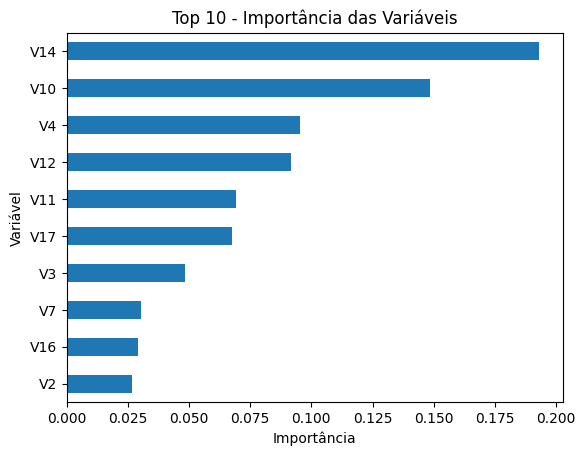

In [98]:
importancias.head(10).sort_values(
    "importance"
).plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Top 10 - Importância das Variáveis")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

In [100]:
import shap

C:\Users\natha\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [101]:
explainer = shap.TreeExplainer(modelo_xgb)

In [102]:

X_test_sample = X_test.sample(
    n=1000,
    random_state=42
)

shap_values = explainer.shap_values(
    X_test_sample
)

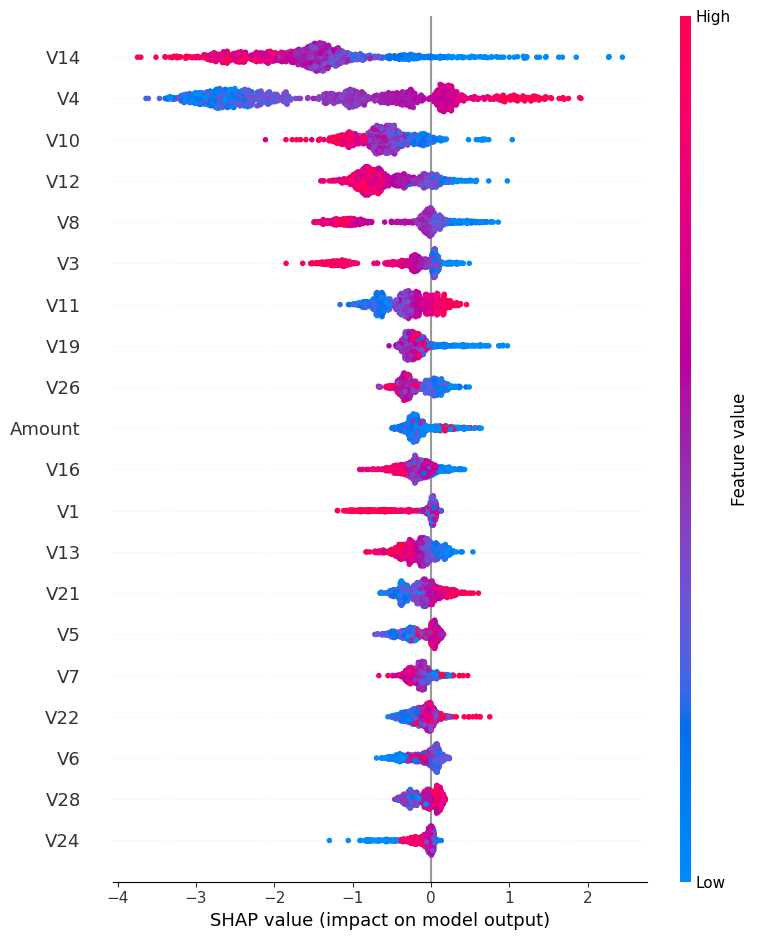

In [103]:
shap.summary_plot(
    shap_values,
    X_test_sample
)

In [105]:
shap.initjs()

In [106]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_sample.iloc[0]
)